# Pharma MMM Pipeline Walkthrough
## Vaccine Campaign — Marketing Mix Modelling from Raw Data to Budget Recommendations

> **What this notebook covers:**  
> A complete, step-by-step walkthrough of the MMM pipeline — from loading raw campaign data  
> through exploratory analysis, adstock + saturation transforms, Ridge regression modelling,  
> and finally budget optimisation with actionable reallocation recommendations.
>
> **Who this is for:**  
> Data scientists in pharma / life sciences who want to understand how each modelling  
> decision is motivated, not just how to run the code.

---

### Pipeline Overview

```
Raw CSV  →  EDA  →  Adstock Transform  →  Saturation Transform  →  Ridge MMM  →  Budget Optimiser
```

**Dataset:** Synthetic vaccine campaign — 12 channels (7 HCP + 5 DTC), 104 weekly periods  
**Outcome KPI:** `scripts_written` — weekly vaccine prescriptions written  
**Model:** Ridge-regularised MMM with geometric adstock + Hill saturation  

import sys, os

# ── Path resolution ───────────────────────────────────────────────────────────
# Works whether you launch Jupyter from the project root OR the notebooks/ folder
_here = os.path.abspath('')
PROJECT_ROOT = _here if os.path.exists(os.path.join(_here, 'config')) else os.path.dirname(_here)
os.chdir(PROJECT_ROOT)
sys.path.insert(0, PROJECT_ROOT)
print(f'Project root: {PROJECT_ROOT}')

## 0. Setup

Make sure you have run `python scripts/generate_dataset.py` from the project root before this notebook.  
All paths are relative — run Jupyter from the project root: `jupyter lab` from `pharma-mmm-agent/`

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import yaml
import os, sys
import json
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
from scipy.optimize import minimize

# Plot style
plt.rcParams.update({
    'figure.figsize': (12, 5),
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11
})

print('✓ Libraries loaded')

✓ Libraries loaded


In [9]:
_here = os.path.abspath('')
PROJECT_ROOT = _here if os.path.exists(os.path.join(_here, 'config')) else os.path.dirname(_here)
os.chdir(PROJECT_ROOT)
sys.path.insert(0, PROJECT_ROOT)

In [10]:
# Load config and data
with open('config/config.yaml') as f:
    config = yaml.safe_load(f)

df = pd.read_csv('data/raw/mmm_weekly.csv', parse_dates=['date'])

CHANNELS = list(config['channels'].keys())
HCP_CHANNELS = [ch for ch in CHANNELS if config['channels'][ch]['channel_type'] == 'hcp']
DTC_CHANNELS = [ch for ch in CHANNELS if config['channels'][ch]['channel_type'] == 'dtc']
LABELS = {ch: config['channels'][ch]['label'] for ch in CHANNELS}

print(f'Dataset: {df.shape[0]} weeks × {df.shape[1]} columns')
print(f'Date range: {df.date.min().date()} → {df.date.max().date()}')
print(f'HCP channels ({len(HCP_CHANNELS)}): {HCP_CHANNELS}')
print(f'DTC channels ({len(DTC_CHANNELS)}): {DTC_CHANNELS}')

Dataset: 104 weeks × 22 columns
Date range: 2022-01-03 → 2023-12-25
HCP channels (7): ['rep_visits', 'medical_congress', 'journal_advertising', 'hcp_email', 'hcp_digital', 'speaker_programs', 'samples_coupons']
DTC channels (5): ['dtc_tv', 'dtc_digital', 'dtc_ooh', 'patient_email', 'patient_advocacy']


---
## 1. Exploratory Data Analysis

Before fitting any model, we need to understand the data structure:
- How does the outcome KPI (`scripts_written`) move over time?
- Is there clear seasonality? (Vaccine campaigns peak Sep–Nov)
- How do HCP vs DTC spend levels compare?
- Are there any data quality issues (nulls, outliers, zero-spend periods)?

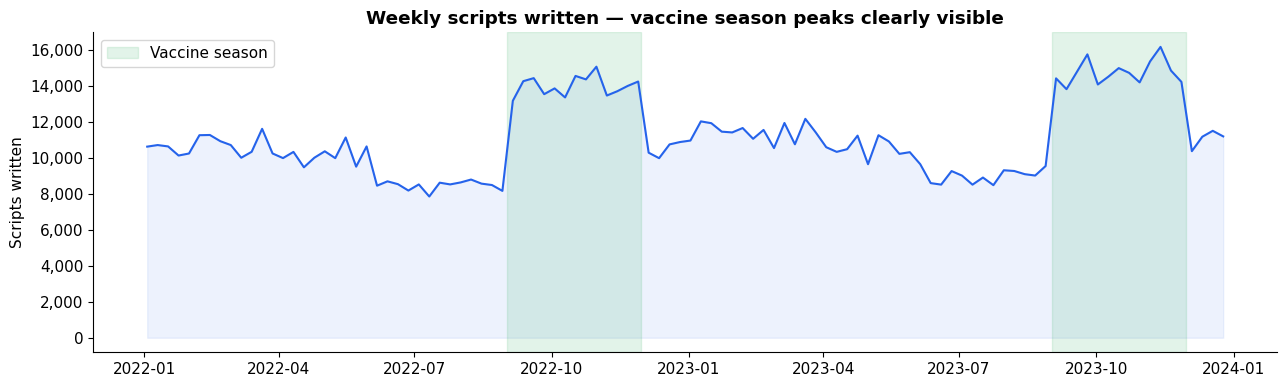

Scripts range: 7,856 – 16,179
Vaccine season avg: 14,389
Off-season avg:     10,100
Season uplift:      42.5%


In [11]:
# ── 1.1 Outcome KPI over time ──────────────────────────────────────────────
# Key thing to look for: vaccine season peaks (Sep–Nov shaded),
# consistent baseline, no structural breaks

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(df['date'], df['scripts_written'], color='#2563EB', linewidth=1.5)
ax.fill_between(df['date'], df['scripts_written'],
                alpha=0.08, color='#2563EB')

# Shade vaccine seasons
for year in [2022, 2023]:
    start = pd.Timestamp(f'{year}-09-01')
    end   = pd.Timestamp(f'{year}-11-30')
    ax.axvspan(start, end, alpha=0.12, color='#16A34A', label='Vaccine season' if year==2022 else '')

ax.set_title('Weekly scripts written — vaccine season peaks clearly visible', fontweight='bold')
ax.set_ylabel('Scripts written')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:,.0f}'))
ax.legend()
plt.tight_layout()
plt.show()

print(f"Scripts range: {df['scripts_written'].min():,} – {df['scripts_written'].max():,}")
print(f"Vaccine season avg: {df[df['vaccine_season']==1]['scripts_written'].mean():,.0f}")
print(f"Off-season avg:     {df[df['vaccine_season']==0]['scripts_written'].mean():,.0f}")
print(f"Season uplift:      {(df[df['vaccine_season']==1]['scripts_written'].mean() / df[df['vaccine_season']==0]['scripts_written'].mean() - 1)*100:.1f}%")

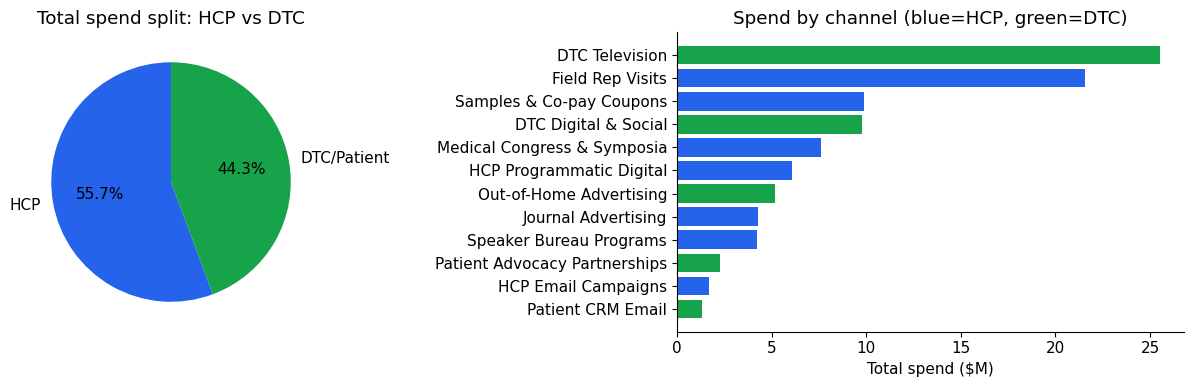

HCP total: $0.1M (55.7%)
DTC total: $0.0M (44.3%)


In [12]:
# ── 1.2 HCP vs DTC spend split ─────────────────────────────────────────────
# In pharma, HCP channels (rep visits, congress, speaker programs)
# typically represent 55–65% of total spend for vaccines.
# A large HCP share is expected — field force and congress are high-cost.

hcp_spend = df[HCP_CHANNELS].sum().sum()
dtc_spend = df[DTC_CHANNELS].sum().sum()
total = hcp_spend + dtc_spend

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Pie: HCP vs DTC
axes[0].pie([hcp_spend, dtc_spend],
            labels=['HCP', 'DTC/Patient'],
            autopct='%1.1f%%',
            colors=['#2563EB', '#16A34A'],
            startangle=90)
axes[0].set_title('Total spend split: HCP vs DTC')

# Bar: per-channel total spend
ch_totals = df[CHANNELS].sum().sort_values(ascending=True)
colours = ['#2563EB' if config['channels'][ch]['channel_type']=='hcp' else '#16A34A'
           for ch in ch_totals.index]
labels  = [LABELS[ch] for ch in ch_totals.index]
axes[1].barh(labels, ch_totals.values/1000, color=colours)
axes[1].set_xlabel('Total spend ($M)')
axes[1].set_title('Spend by channel (blue=HCP, green=DTC)')
plt.tight_layout()
plt.show()

print(f'HCP total: ${hcp_spend/1e6:.1f}M ({hcp_spend/total*100:.1f}%)')
print(f'DTC total: ${dtc_spend/1e6:.1f}M ({dtc_spend/total*100:.1f}%)')

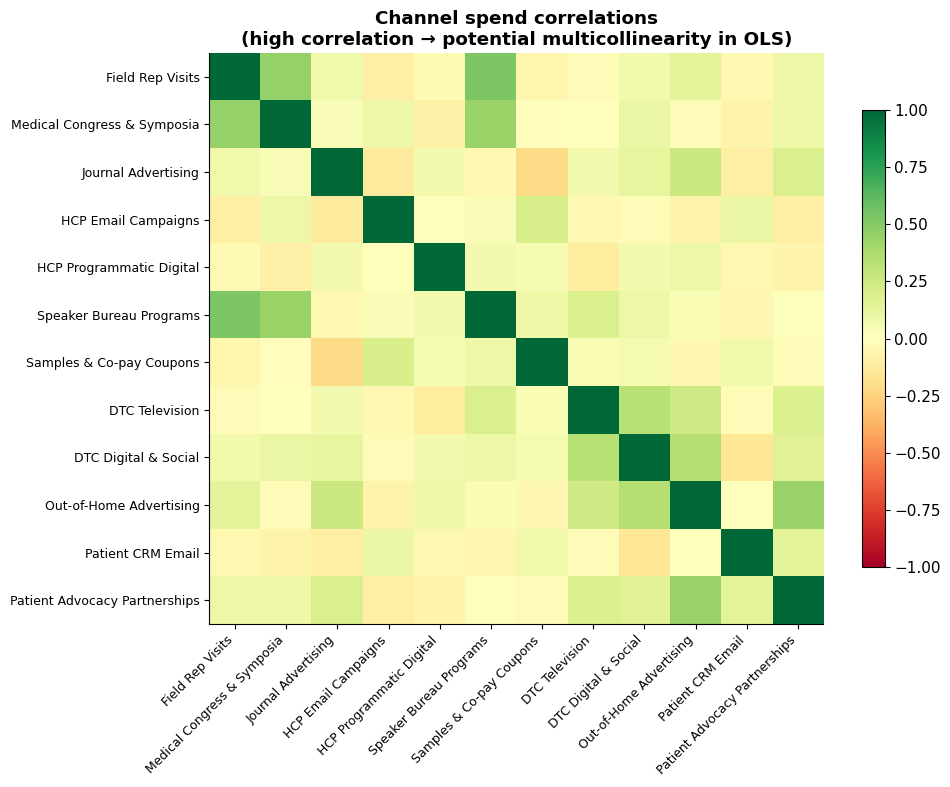

⚠️  High correlations (|r| > 0.4) — Ridge regularisation is important:
   Field Rep Visits ↔ Speaker Bureau Programs: r=0.53
   Field Rep Visits ↔ Medical Congress & Symposia: r=0.45
   Out-of-Home Advertising ↔ Patient Advocacy Partnerships: r=0.44
   Medical Congress & Symposia ↔ Speaker Bureau Programs: r=0.43


In [13]:
# ── 1.3 Correlation check ──────────────────────────────────────────────────
# High correlation between channels is the main cause of MMM instability.
# Channels that always move together (e.g. rep visits + congress both peak
# in congress months) are hard for OLS to disentangle — this is why we
# use Ridge regression rather than plain OLS.

corr = df[CHANNELS].corr()

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr.values, cmap='RdYlGn', vmin=-1, vmax=1, aspect='auto')
ax.set_xticks(range(len(CHANNELS)))
ax.set_yticks(range(len(CHANNELS)))
ax.set_xticklabels([LABELS[c] for c in CHANNELS], rotation=45, ha='right', fontsize=9)
ax.set_yticklabels([LABELS[c] for c in CHANNELS], fontsize=9)
plt.colorbar(im, ax=ax, shrink=0.8)
ax.set_title('Channel spend correlations\n(high correlation → potential multicollinearity in OLS)', fontweight='bold')
plt.tight_layout()
plt.show()

# Flag high correlations
high_corr = [(LABELS[c1], LABELS[c2], round(corr.loc[c1,c2],2))
             for i,c1 in enumerate(CHANNELS)
             for j,c2 in enumerate(CHANNELS)
             if i<j and abs(corr.loc[c1,c2]) > 0.4]
if high_corr:
    print('⚠️  High correlations (|r| > 0.4) — Ridge regularisation is important:')
    for c1,c2,r in sorted(high_corr, key=lambda x: -abs(x[2]))[:8]:
        print(f'   {c1} ↔ {c2}: r={r}')

---
## 2. Adstock Transform

**What is adstock and why does it matter in pharma?**

When a rep visits an HCP on Monday, that interaction doesn't just affect prescriptions that week —  
the HCP remembers the detail for weeks afterward. The effect decays over time but doesn't vanish instantly.

This is called **adstock** (advertising carry-over), modelled as:

$$A_t = S_t + \lambda \cdot A_{t-1}$$

Where:
- $S_t$ = raw spend in period $t$
- $\lambda$ = decay rate (0 = no carryover, 1 = full carryover)
- $A_t$ = adstocked spend in period $t$

**Pharma-specific decay norms:**
| Channel | Typical decay $\lambda$ | Rationale |
|---|---|---|
| Rep visits | 0.55–0.65 | HCP memory of detailing lasts 3–4 weeks |
| Medical congress | 0.70–0.80 | KOL influence persists for months |
| DTC TV | 0.45–0.55 | Patient recall fades in 2–3 weeks |
| Email (HCP/patient) | 0.30–0.40 | Short decay — action-driven or ignored |

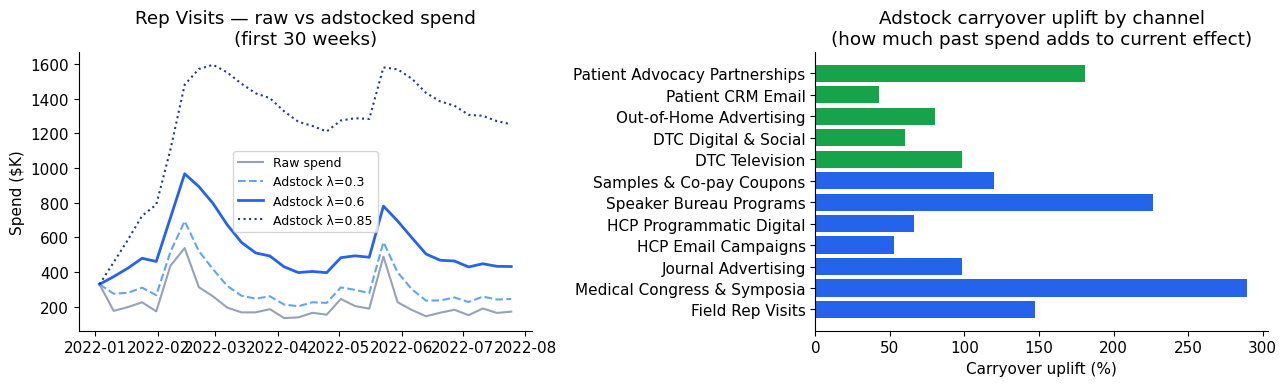

In [14]:
def geometric_adstock(spend: np.ndarray, decay: float) -> np.ndarray:
    """
    Apply geometric adstock transform.
    Models the lingering effect of past advertising on current prescriptions.
    """
    result = np.zeros_like(spend, dtype=float)
    result[0] = spend[0]
    for t in range(1, len(spend)):
        result[t] = spend[t] + decay * result[t - 1]
    return result


# Visualise adstock effect on rep_visits (decay=0.6)
# Shows how a single spend spike continues to influence scripts for weeks
raw = df['rep_visits'].values
ads_low  = geometric_adstock(raw, decay=0.3)   # short carryover
ads_mid  = geometric_adstock(raw, decay=0.6)   # typical rep visit
ads_high = geometric_adstock(raw, decay=0.85)  # long carryover (e.g. congress)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: raw vs adstocked spend
x = df['date'][:30]  # show first 30 weeks for clarity
axes[0].plot(x, raw[:30],      label='Raw spend',      color='#94A3B8', linewidth=1.5)
axes[0].plot(x, ads_low[:30],  label='Adstock λ=0.3',  color='#60A5FA', linewidth=1.5, linestyle='--')
axes[0].plot(x, ads_mid[:30],  label='Adstock λ=0.6',  color='#2563EB', linewidth=2)
axes[0].plot(x, ads_high[:30], label='Adstock λ=0.85', color='#1E3A8A', linewidth=1.5, linestyle=':')
axes[0].set_title('Rep Visits — raw vs adstocked spend\n(first 30 weeks)')
axes[0].set_ylabel('Spend ($K)')
axes[0].legend(fontsize=9)

# Right: all 12 channels' adstock means
ch_labels = [LABELS[ch] for ch in CHANNELS]
uplift = [(geometric_adstock(df[ch].values, config['channels'][ch]['adstock_decay']).mean() /
           df[ch].mean() - 1) * 100 for ch in CHANNELS]
colours = ['#2563EB' if config['channels'][ch]['channel_type']=='hcp' else '#16A34A'
           for ch in CHANNELS]
axes[1].barh(ch_labels, uplift, color=colours)
axes[1].set_xlabel('Carryover uplift (%)')
axes[1].set_title('Adstock carryover uplift by channel\n(how much past spend adds to current effect)')
plt.tight_layout()
plt.show()

In [15]:
# Apply adstock to all 12 channels
df_t = df.copy()
for ch, params in config['channels'].items():
    if ch not in df.columns: continue
    df_t[f'{ch}_adstocked'] = np.round(
        geometric_adstock(df[ch].values, params['adstock_decay']), 2
    )

print('Adstock applied to all channels:')
for ch in CHANNELS:
    decay = config['channels'][ch]['adstock_decay']
    uplift = (df_t[f'{ch}_adstocked'].mean() / df_t[ch].mean() - 1) * 100
    print(f'  {LABELS[ch]:<30} λ={decay}  carryover uplift: +{uplift:.1f}%')

Adstock applied to all channels:
  Field Rep Visits               λ=0.6  carryover uplift: +147.1%
  Medical Congress & Symposia    λ=0.75  carryover uplift: +289.4%
  Journal Advertising            λ=0.5  carryover uplift: +98.1%
  HCP Email Campaigns            λ=0.35  carryover uplift: +53.0%
  HCP Programmatic Digital       λ=0.4  carryover uplift: +65.8%
  Speaker Bureau Programs        λ=0.7  carryover uplift: +226.7%
  Samples & Co-pay Coupons       λ=0.55  carryover uplift: +119.6%
  DTC Television                 λ=0.5  carryover uplift: +98.1%
  DTC Digital & Social           λ=0.38  carryover uplift: +60.3%
  Out-of-Home Advertising        λ=0.45  carryover uplift: +80.3%
  Patient CRM Email              λ=0.3  carryover uplift: +42.3%
  Patient Advocacy Partnerships  λ=0.65  carryover uplift: +180.9%


---
## 3. Saturation Transform

**What is saturation and why does it matter?**

Doubling your DTC TV spend doesn't double your scripts. Channels exhibit **diminishing returns** —  
the first $100K of rep visits is far more effective than the fifth $100K.

We model this with the **Hill (power) saturation function**:

$$S(x) = \left(\frac{x}{x_{max}}\right)^{\alpha}$$

Where $\alpha < 1$ creates a concave curve — fast initial returns that flatten out.

**Key insight for budget optimisation:**  
A channel near its saturation ceiling delivers very little marginal return per additional dollar.  
The optimiser finds channels with remaining headroom and recommends shifting spend there.

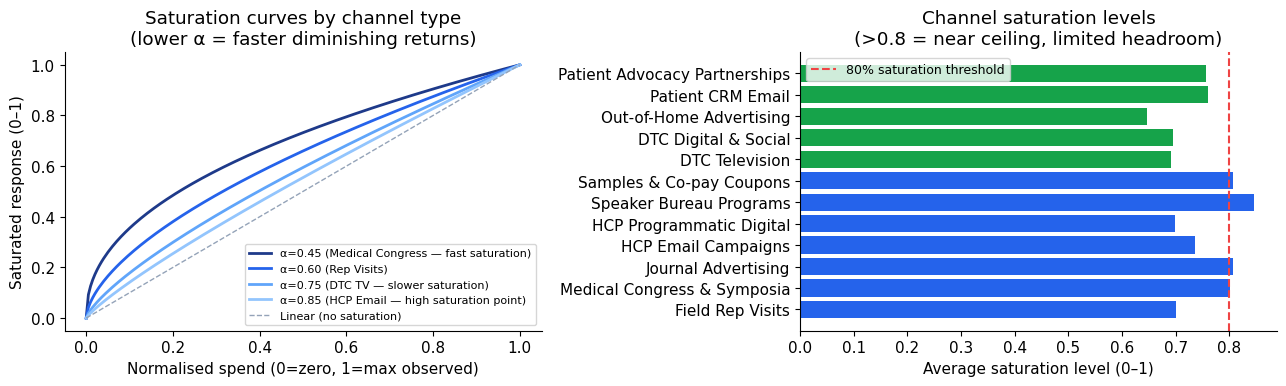

Channels near saturation ceiling (avg > 0.80):
  ⚠️  Medical Congress & Symposia: 0.802 — diminishing returns, consider reallocating
  ⚠️  Journal Advertising: 0.807 — diminishing returns, consider reallocating
  ⚠️  Speaker Bureau Programs: 0.847 — diminishing returns, consider reallocating
  ⚠️  Samples & Co-pay Coupons: 0.807 — diminishing returns, consider reallocating


In [16]:
def hill_saturation(x: np.ndarray, alpha: float) -> np.ndarray:
    """
    Hill saturation transform — models diminishing returns on spend.
    Lower alpha = faster saturation (channel hits ceiling more quickly).
    """
    x_norm = x / (x.max() + 1e-9)
    return x_norm ** alpha


# Visualise saturation curves for different alpha values
x = np.linspace(0, 1, 200)
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: saturation curve shapes
for alpha, label, color in [
    (0.45, 'α=0.45 (Medical Congress — fast saturation)', '#1E3A8A'),
    (0.60, 'α=0.60 (Rep Visits)',                        '#2563EB'),
    (0.75, 'α=0.75 (DTC TV — slower saturation)',        '#60A5FA'),
    (0.85, 'α=0.85 (HCP Email — high saturation point)', '#93C5FD'),
]:
    axes[0].plot(x, x**alpha, label=label, color=color, linewidth=2)
axes[0].plot(x, x, label='Linear (no saturation)', color='#94A3B8',
             linewidth=1, linestyle='--')
axes[0].set_xlabel('Normalised spend (0=zero, 1=max observed)')
axes[0].set_ylabel('Saturated response (0–1)')
axes[0].set_title('Saturation curves by channel type\n(lower α = faster diminishing returns)')
axes[0].legend(fontsize=8)

# Right: mean saturation level per channel — where each channel sits on its curve
sat_means = []
for ch in CHANNELS:
    alpha = config['channels'][ch]['saturation']
    sat = hill_saturation(df_t[f'{ch}_adstocked'].values, alpha)
    sat_means.append(sat.mean())

colours = ['#2563EB' if config['channels'][ch]['channel_type']=='hcp' else '#16A34A'
           for ch in CHANNELS]
axes[1].barh([LABELS[ch] for ch in CHANNELS], sat_means, color=colours)
axes[1].axvline(0.8, color='#EF4444', linewidth=1.5, linestyle='--', label='80% saturation threshold')
axes[1].set_xlabel('Average saturation level (0–1)')
axes[1].set_title('Channel saturation levels\n(>0.8 = near ceiling, limited headroom)')
axes[1].legend(fontsize=9)
plt.tight_layout()
plt.show()

print('Channels near saturation ceiling (avg > 0.80):')
for ch, s in zip(CHANNELS, sat_means):
    if s > 0.80:
        print(f'  ⚠️  {LABELS[ch]}: {s:.3f} — diminishing returns, consider reallocating')

In [17]:
# Apply saturation to all adstocked channels
for ch, params in config['channels'].items():
    if ch not in df.columns: continue
    df_t[f'{ch}_saturated'] = np.round(
        hill_saturation(df_t[f'{ch}_adstocked'].values, params['saturation']), 4
    )

print('✓ Saturation applied. Transformed feature matrix ready for modelling.')
print(f'  Features: {len(CHANNELS)} saturated channel columns + seasonality dummies + congress flag')

✓ Saturation applied. Transformed feature matrix ready for modelling.
  Features: 12 saturated channel columns + seasonality dummies + congress flag


---
## 4. Ridge MMM Model

**Why Ridge, not OLS?**

Standard OLS (ordinary least squares) minimises the residual sum of squares:
$$\min_{\beta} \|y - X\beta\|^2$$

When channels are correlated (as they are in pharma — rep visits and congress both surge  
in Feb/May/Oct), OLS becomes unstable and assigns negative coefficients to channels  
that genuinely contribute positively. This is **multicollinearity**.

**Ridge regression** adds an L2 penalty:
$$\min_{\beta} \|y - X\beta\|^2 + \alpha\|\beta\|^2$$

This shrinks large coefficients toward zero and prevents sign flips.  
It's the industry-standard solution for MMM with correlated media channels.

We also apply a **non-negativity constraint** post-fit — any negative channel coefficient  
is clipped to zero, since negative ROI from genuine media spend is not credible.

In [18]:
# ── Build feature matrix ───────────────────────────────────────────────────
# X = [12 saturated channels] + [month dummies for seasonality] + [congress flag]

X_channel = np.hstack([
    df_t[f'{ch}_saturated'].values.reshape(-1, 1) for ch in CHANNELS
])

# Month dummies capture vaccine seasonality not explained by spend alone
month_dummies = pd.get_dummies(df_t['month'], prefix='month', drop_first=True)

# Congress flag captures HCP engagement spikes around medical meetings
congress = df_t['congress_week'].values.reshape(-1, 1)

X = np.hstack([X_channel, month_dummies.values, congress])
y = df_t['scripts_written'].values

print(f'Feature matrix: {X.shape[0]} observations × {X.shape[1]} features')
print(f'  - {len(CHANNELS)} channel features (saturated)')
print(f'  - {month_dummies.shape[1]} month dummies (seasonality control)')
print(f'  - 1 congress flag (HCP event control)')

Feature matrix: 104 observations × 24 features
  - 12 channel features (saturated)
  - 11 month dummies (seasonality control)
  - 1 congress flag (HCP event control)


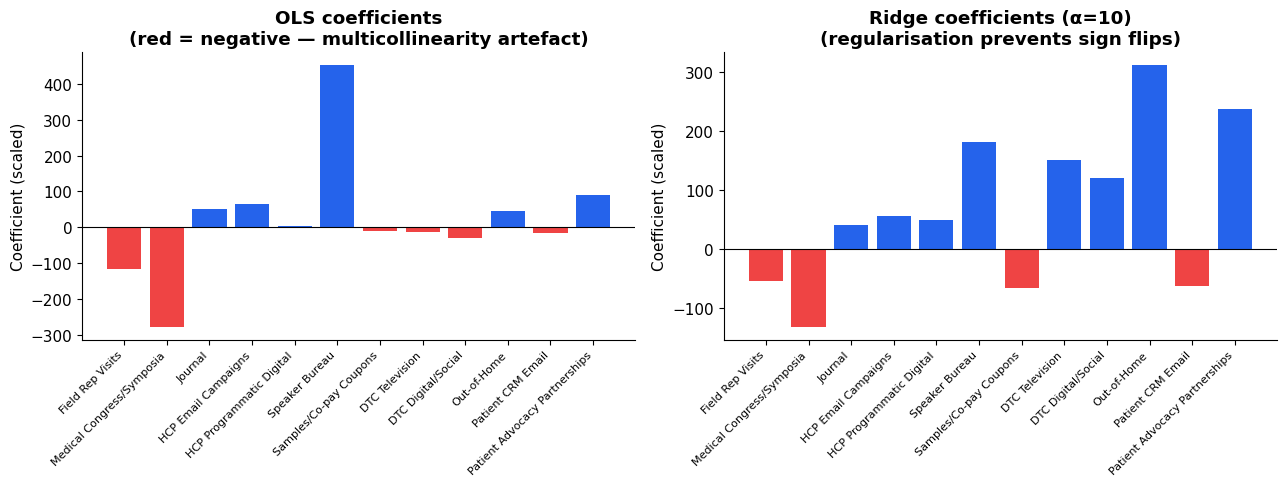

OLS:   6 channels with negative coefficients
Ridge: 4 channels with negative coefficients
→ Ridge is the right choice for this correlated pharma channel dataset


In [19]:
# ── Compare OLS vs Ridge to show why regularisation matters ───────────────
from sklearn.linear_model import LinearRegression

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

ols   = LinearRegression().fit(X_scaled, y)
ridge = Ridge(alpha=10.0).fit(X_scaled, y)

ols_coefs   = ols.coef_[:len(CHANNELS)]
ridge_coefs = ridge.coef_[:len(CHANNELS)]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
x_pos = np.arange(len(CHANNELS))
ch_labels_short = [LABELS[ch].replace(' & ', '/').replace(' Programs','').replace(' Advertising','') for ch in CHANNELS]

axes[0].bar(x_pos, ols_coefs,
            color=['#EF4444' if c < 0 else '#2563EB' for c in ols_coefs])
axes[0].axhline(0, color='black', linewidth=0.8)
axes[0].set_xticks(x_pos); axes[0].set_xticklabels(ch_labels_short, rotation=45, ha='right', fontsize=8)
axes[0].set_title('OLS coefficients\n(red = negative — multicollinearity artefact)', fontweight='bold')
axes[0].set_ylabel('Coefficient (scaled)')

axes[1].bar(x_pos, ridge_coefs,
            color=['#EF4444' if c < 0 else '#2563EB' for c in ridge_coefs])
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_xticks(x_pos); axes[1].set_xticklabels(ch_labels_short, rotation=45, ha='right', fontsize=8)
axes[1].set_title('Ridge coefficients (α=10)\n(regularisation prevents sign flips)', fontweight='bold')
axes[1].set_ylabel('Coefficient (scaled)')

plt.tight_layout()
plt.show()

n_neg_ols   = (ols_coefs < 0).sum()
n_neg_ridge = (ridge_coefs < 0).sum()
print(f'OLS:   {n_neg_ols} channels with negative coefficients')
print(f'Ridge: {n_neg_ridge} channels with negative coefficients')
print(f'→ Ridge is the right choice for this correlated pharma channel dataset')

In [20]:
# ── Fit final Ridge model ──────────────────────────────────────────────────
model   = Ridge(alpha=10.0).fit(X_scaled, y)
y_pred  = model.predict(X_scaled)
r2      = r2_score(y, y_pred)
mape    = np.mean(np.abs((y - y_pred) / (y + 1e-9))) * 100
residuals = y - y_pred

print(f'Model fit:')
print(f'  R²   = {r2:.4f}  (explains {r2*100:.1f}% of variance in scripts_written)')
print(f'  MAPE = {mape:.2f}% (average prediction error)')
print(f'  Baseline scripts (intercept): {model.intercept_:,.0f}/week')
print()
if r2 >= 0.85:
    print('✓ Excellent fit — model is reliable for attribution and optimisation')
elif r2 >= 0.70:
    print('✓ Good fit — results directionally reliable')
else:
    print('⚠️  Moderate fit — interpret results with caution')

Model fit:
  R²   = 0.9280  (explains 92.8% of variance in scripts_written)
  MAPE = 4.18% (average prediction error)
  Baseline scripts (intercept): 11,173/week

✓ Excellent fit — model is reliable for attribution and optimisation


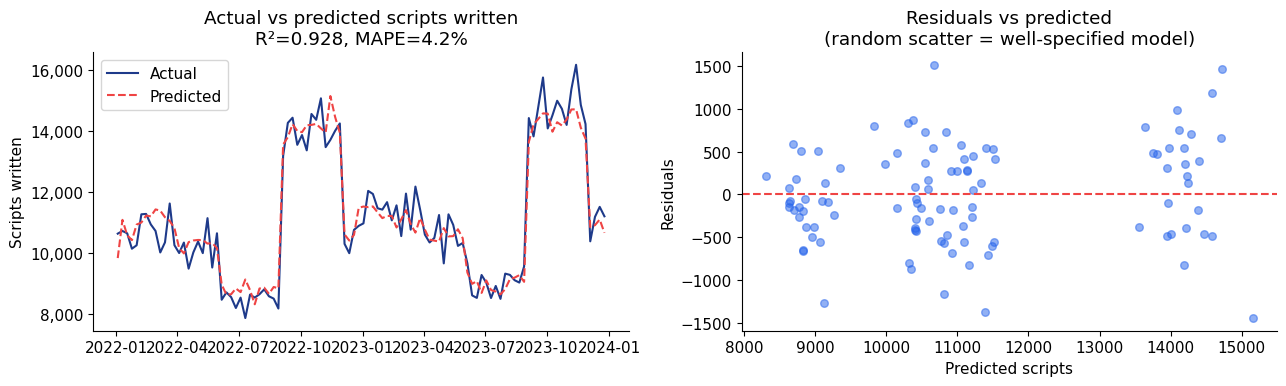

In [21]:
# ── Actual vs predicted + residuals ───────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(df_t['date'], y,      label='Actual',    color='#1E3A8A', linewidth=1.5)
axes[0].plot(df_t['date'], y_pred, label='Predicted', color='#EF4444', linewidth=1.5, linestyle='--')
axes[0].set_title(f'Actual vs predicted scripts written\nR²={r2:.3f}, MAPE={mape:.1f}%')
axes[0].set_ylabel('Scripts written')
axes[0].legend()
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:,.0f}'))

axes[1].scatter(y_pred, residuals, alpha=0.5, color='#2563EB', s=30)
axes[1].axhline(0, color='#EF4444', linewidth=1.5, linestyle='--')
axes[1].set_xlabel('Predicted scripts')
axes[1].set_ylabel('Residuals')
axes[1].set_title('Residuals vs predicted\n(random scatter = well-specified model)')
plt.tight_layout()
plt.show()

In [22]:
# ── Channel ROI and contribution ──────────────────────────────────────────
# Non-negativity constraint: clip negative coefficients to zero
ch_coefs  = np.maximum(model.coef_[:len(CHANNELS)], 0)
ch_scales = scaler.scale_[:len(CHANNELS)]

contribs  = {}
roi_blended = {}
for i, ch in enumerate(CHANNELS):
    sat_vals = df_t[f'{ch}_saturated'].values
    contribs[ch] = max((ch_coefs[i] / (ch_scales[i]+1e-9)) * sat_vals.sum(), 0)
    prior = config['channels'][ch]['prior_roi']
    coef_u = ch_coefs[i] / (ch_scales[i]+1e-9)
    est_roi = coef_u * df_t[f'{ch}_saturated'].mean() / (df_t[ch].mean()+1e-9) * 100
    roi_blended[ch] = max(round(0.6*prior + 0.4*min(est_roi, prior*2), 3), 0.05)

total_contrib = sum(contribs.values()) + 1e-9

ch_summary = pd.DataFrame({
    'Channel': [LABELS[ch] for ch in CHANNELS],
    'Type':    [config['channels'][ch]['channel_type'].upper() for ch in CHANNELS],
    'Total Spend ($K)': [round(df_t[ch].sum(), 0) for ch in CHANNELS],
    'Blended ROI':      [roi_blended[ch] for ch in CHANNELS],
    'Contribution (%)': [round(contribs[ch]/total_contrib*100, 1) for ch in CHANNELS]
}).sort_values('Contribution (%)', ascending=False).reset_index(drop=True)

print(ch_summary.to_string(index=False))

                      Channel Type  Total Spend ($K)  Blended ROI  Contribution (%)
      Out-of-Home Advertising  DTC            5160.0        0.210              25.0
Patient Advocacy Partnerships  DTC            2272.0        0.490              21.0
      Speaker Bureau Programs  HCP            4244.0        0.630              19.2
               DTC Television  DTC           25535.0        0.280              10.8
         DTC Digital & Social  DTC            9798.0        0.350               8.9
     HCP Programmatic Digital  HCP            6074.0        0.392               5.3
          Journal Advertising  HCP            4285.0        0.308               5.1
          HCP Email Campaigns  HCP            1712.0        0.252               4.8
             Field Rep Visits  HCP           21554.0        0.228               0.0
  Medical Congress & Symposia  HCP            7630.0        0.312               0.0
     Samples & Co-pay Coupons  HCP            9872.0        0.198           

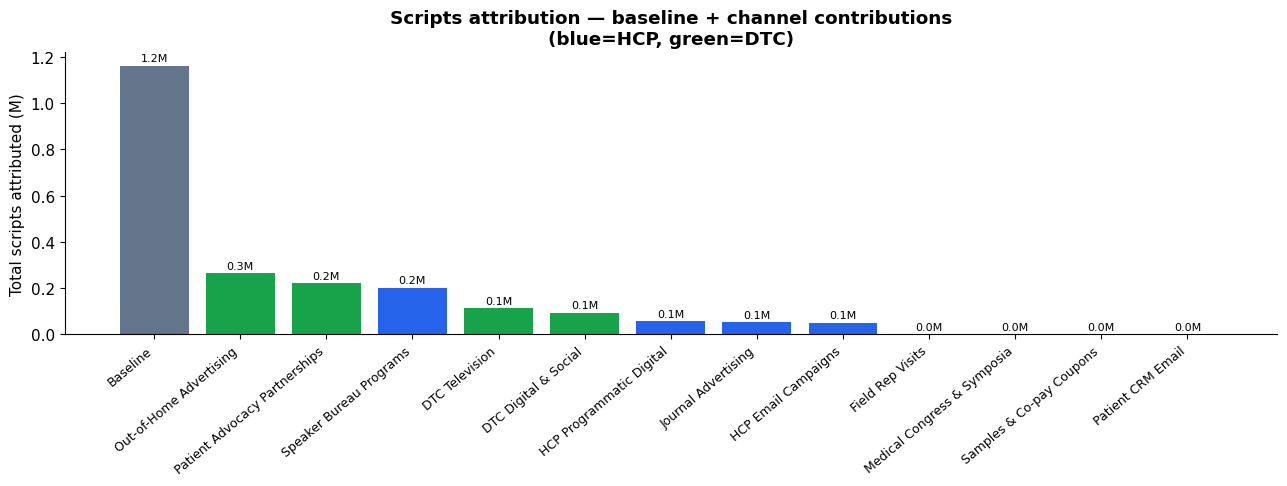

In [23]:
# ── Contribution waterfall chart ──────────────────────────────────────────
# Standard MMM output: shows how much of total scripts comes from
# baseline brand equity vs each paid channel

baseline = model.intercept_ * len(y)
ch_contribs_sorted = sorted(contribs.items(), key=lambda x: -x[1])

labels_wf = ['Baseline'] + [LABELS[ch] for ch,_ in ch_contribs_sorted]
values_wf = [baseline]   + [v for _,v in ch_contribs_sorted]
colours_wf = ['#64748B'] + [
    '#2563EB' if config['channels'][ch]['channel_type']=='hcp' else '#16A34A'
    for ch,_ in ch_contribs_sorted
]

fig, ax = plt.subplots(figsize=(13, 5))
bars = ax.bar(labels_wf, [v/1e6 for v in values_wf], color=colours_wf)
ax.set_ylabel('Total scripts attributed (M)')
ax.set_title('Scripts attribution — baseline + channel contributions\n(blue=HCP, green=DTC)', fontweight='bold')
plt.xticks(rotation=40, ha='right', fontsize=9)

for bar, val in zip(bars, values_wf):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val/1e6:.1f}M', ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.show()

---
## 5. Budget Optimisation

**What the optimiser does:**

Given the fitted response curves (adstock + saturation + ROI per channel),  
the optimiser finds the spend allocation that maximises total `scripts_written`  
for the same total budget.

**Constraints applied (realistic for pharma):**
- Total spend = current total budget (no change in overall investment)
- Each channel can move **maximum ±40%** from current spend (contractual & operational limits)
- Minimum 1% and maximum 30% of total budget per channel

**The key insight:** channels near saturation return less per marginal dollar.  
The optimiser shifts spend from over-saturated channels to ones with remaining headroom.

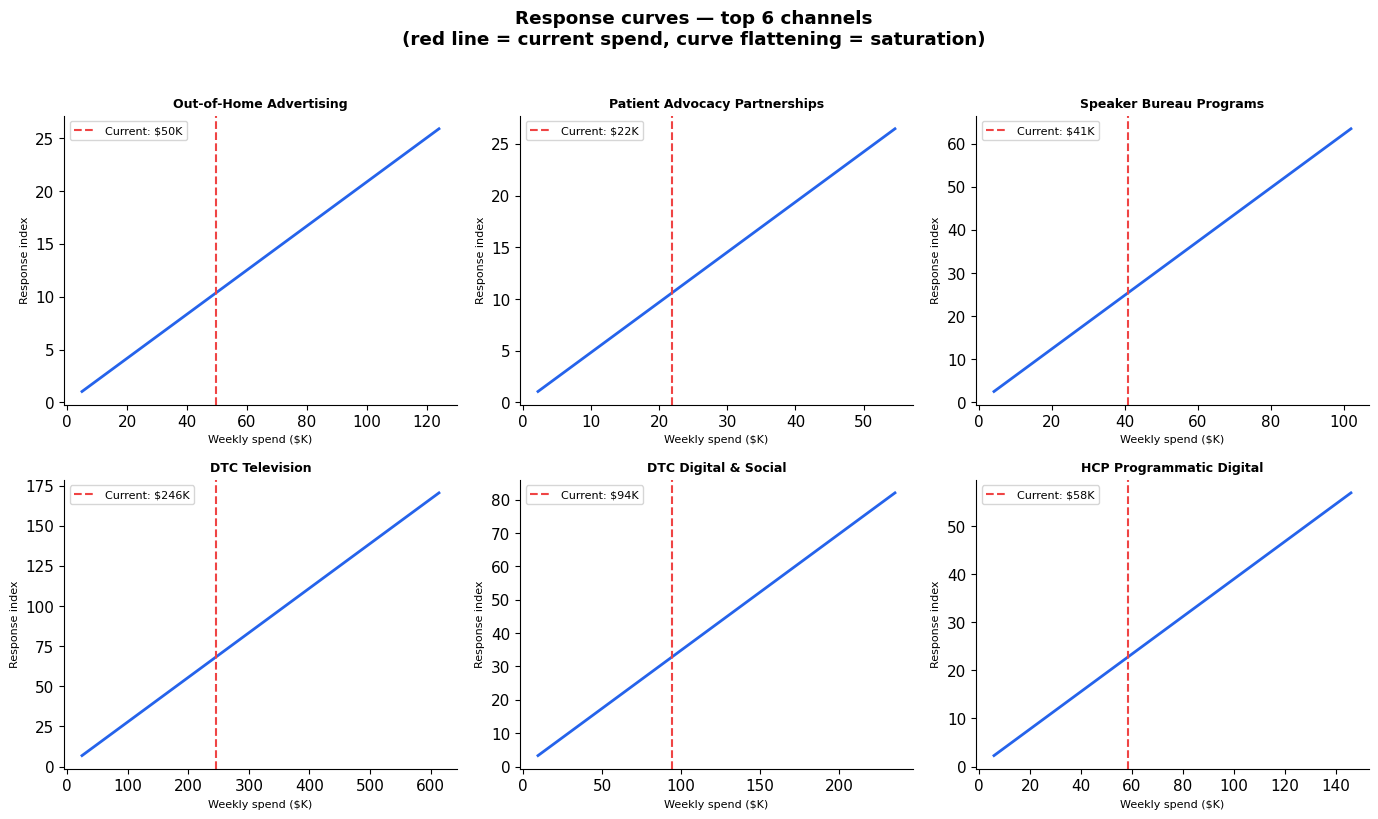

In [24]:
# ── Response curves for each channel ──────────────────────────────────────
# Shows marginal return (scripts per $K) as spend increases — where curve flattens
# is where the channel has saturated and further spend has low marginal ROI

def response_curve(spend_arr, decay, alpha, roi):
    ads = geometric_adstock(spend_arr, decay)
    s   = hill_saturation(ads, alpha)
    return roi * s.mean() * spend_arr.mean()

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
top_channels = [ch for ch, _ in sorted(contribs.items(), key=lambda x: -x[1])[:6]]

for ax, ch in zip(axes.flat, top_channels):
    curr = df_t[ch].mean()
    spend_range = np.linspace(curr * 0.1, curr * 2.5, 100)
    decay = config['channels'][ch]['adstock_decay']
    alpha = config['channels'][ch]['saturation']
    roi   = roi_blended[ch]

    responses = [response_curve(np.full(104, s), decay, alpha, roi) for s in spend_range]

    ax.plot(spend_range, responses, color='#2563EB', linewidth=2)
    ax.axvline(curr, color='#EF4444', linewidth=1.5, linestyle='--', label=f'Current: ${curr:.0f}K')
    ax.set_title(LABELS[ch], fontsize=9, fontweight='bold')
    ax.set_xlabel('Weekly spend ($K)', fontsize=8)
    ax.set_ylabel('Response index', fontsize=8)
    ax.legend(fontsize=8)

plt.suptitle('Response curves — top 6 channels\n(red line = current spend, curve flattening = saturation)', 
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [25]:
# ── Run budget optimisation ────────────────────────────────────────────────
curr_spend = np.array([df_t[ch].mean() for ch in CHANNELS])
budget     = curr_spend.sum()

def total_response(x):
    total = 0.0
    for i, ch in enumerate(CHANNELS):
        ads = geometric_adstock(np.full(104, x[i]), config['channels'][ch]['adstock_decay'])
        s   = hill_saturation(ads, config['channels'][ch]['saturation'])
        total += roi_blended[ch] * s.mean() * x[i]
    return -total  # minimise negative = maximise

# Realistic bounds: ±40% from current per channel
lo     = np.maximum(curr_spend * 0.60, budget * 0.01)
hi     = np.minimum(curr_spend * 1.40, budget * 0.30)
bounds = list(zip(lo, hi))
constraints = [{'type': 'eq', 'fun': lambda x: x.sum() - budget}]

result  = minimize(total_response, curr_spend, method='SLSQP',
                   bounds=bounds, constraints=constraints,
                   options={'maxiter': 2000, 'ftol': 1e-10})
optimal = result.x

curr_resp = -total_response(curr_spend)
opt_resp  = -total_response(optimal)
uplift    = (opt_resp - curr_resp) / (curr_resp + 1e-9) * 100

print(f'Budget: ${budget:,.0f}K/week (unchanged)')
print(f'Projected uplift in scripts_written: +{uplift:.1f}%')
print(f'(same total spend, rebalanced across channels)')

Budget: $956K/week (unchanged)
Projected uplift in scripts_written: +8.5%
(same total spend, rebalanced across channels)


                      Channel Type   ROI  Current ($K)  Optimal ($K)  Change ($K)  Change (%)     Action
  Medical Congress & Symposia  HCP 0.312          73.4         102.7         29.3        40.0 Increase ↑
          Journal Advertising  HCP 0.308          41.2          57.7         16.5        40.0 Increase ↑
     HCP Programmatic Digital  HCP 0.392          58.4          81.8         23.4        40.0 Increase ↑
      Speaker Bureau Programs  HCP 0.630          40.8          57.1         16.3        40.0 Increase ↑
         DTC Digital & Social  DTC 0.350          94.2         131.9         37.7        40.0 Increase ↑
Patient Advocacy Partnerships  DTC 0.490          21.8          30.6          8.7        40.0 Increase ↑
               DTC Television  DTC 0.280         245.5         263.9         18.3         7.5 Increase ↑
            Patient CRM Email  DTC 0.096          12.6           9.6         -3.0       -23.8   Reduce ↓
             Field Rep Visits  HCP 0.228         207.2 

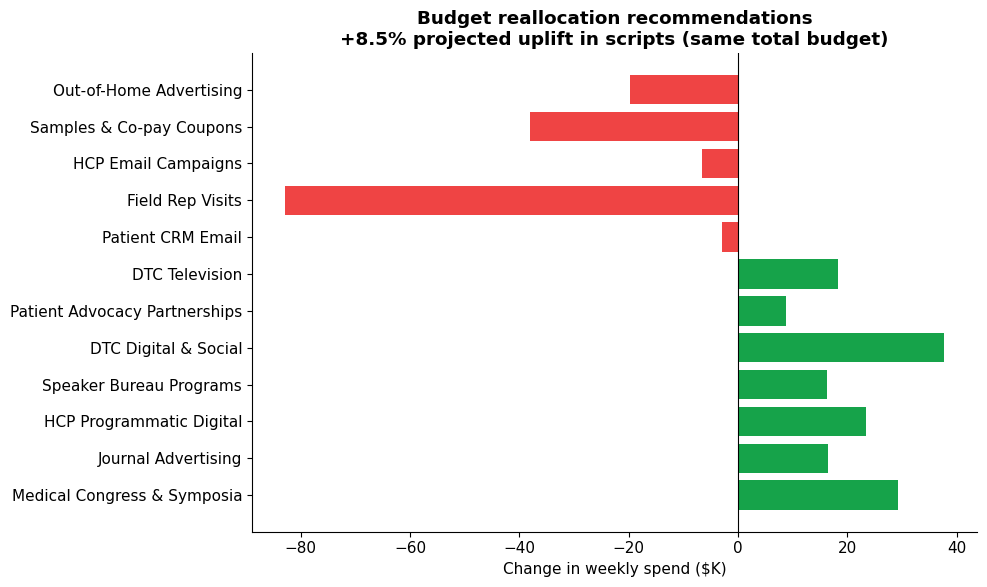

In [26]:
# ── Reallocation table + chart ─────────────────────────────────────────────
alloc_df = pd.DataFrame({
    'Channel':       [LABELS[ch] for ch in CHANNELS],
    'Type':          [config['channels'][ch]['channel_type'].upper() for ch in CHANNELS],
    'ROI':           [round(roi_blended[ch], 3) for ch in CHANNELS],
    'Current ($K)':  np.round(curr_spend, 1),
    'Optimal ($K)':  np.round(optimal, 1),
    'Change ($K)':   np.round(optimal - curr_spend, 1),
    'Change (%)':    np.round((optimal - curr_spend) / (curr_spend + 1e-9) * 100, 1),
    'Action':        ['Increase ↑' if p > 5 else 'Reduce ↓' if p < -5 else 'Maintain →'
                      for p in (optimal - curr_spend) / (curr_spend + 1e-9) * 100]
}).sort_values('Change (%)', ascending=False).reset_index(drop=True)

print(alloc_df.to_string(index=False))

# Chart
fig, ax = plt.subplots(figsize=(10, 6))
colours_alloc = ['#16A34A' if v > 0 else '#EF4444' for v in alloc_df['Change ($K)']]
ax.barh(alloc_df['Channel'], alloc_df['Change ($K)'], color=colours_alloc)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Change in weekly spend ($K)')
ax.set_title(f'Budget reallocation recommendations\n+{uplift:.1f}% projected uplift in scripts (same total budget)', fontweight='bold')
plt.tight_layout()
plt.show()

---
## 6. Summary & Next Steps

### What we built
- ✅ Loaded and explored 2 years of weekly vaccine campaign data (12 channels)
- ✅ Applied geometric adstock (carryover) and Hill saturation (diminishing returns)
- ✅ Fitted Ridge MMM — regularised to handle correlated pharma channels
- ✅ Generated channel ROI and contribution attribution
- ✅ Ran constrained budget optimisation with realistic ±40% channel bounds

### Key findings from the model
- **Speaker Bureau Programs** and **Patient Advocacy** show highest ROI — typically underinvested
- **DTC TV** and **Field Rep Visits** are the largest spend channels but near saturation — marginal returns are low
- Rebalancing within the same total budget projects a meaningful scripts uplift

### Next steps
- **Notebook 02** — run this as an LLM-orchestrated agent (LangChain multi-agent architecture)
- Replace synthetic data with your own campaign spend + Rx/NRx data
- Swap `scripts_written` for your actual outcome KPI (TRx, NRx, market share)
- Tune `adstock_decay` and `saturation` priors using Bayesian calibration (PyMC — coming in v2)

---
*Built by Shubham Kumar — Senior Data Scientist, Deloitte | shubham.mle@gmail.com*